# Task5: Sales prediction Project

# Author: Odeyale Kehinde Musiliudeen

# Task Description: Sales Prediction means predicting how much of product people will buy based on factors such as amount you spend to advertise your product, the segment of people you advertise for, or the platform you used for the advertisement.

# Step 1: Import necessary Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  r2_score, mean_squared_error, mean_absolute_error
import joblib


# Step 2: Load the Sales Dataset

In [2]:
df = pd.read_csv("Advertising.csv")

In [3]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
duplicates=df.duplicated()
duplicates

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [6]:
duplicates=sum(df.duplicated())
duplicates

0

# Step 3: Exploratory Data Analysis (EDA)

In [7]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [8]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


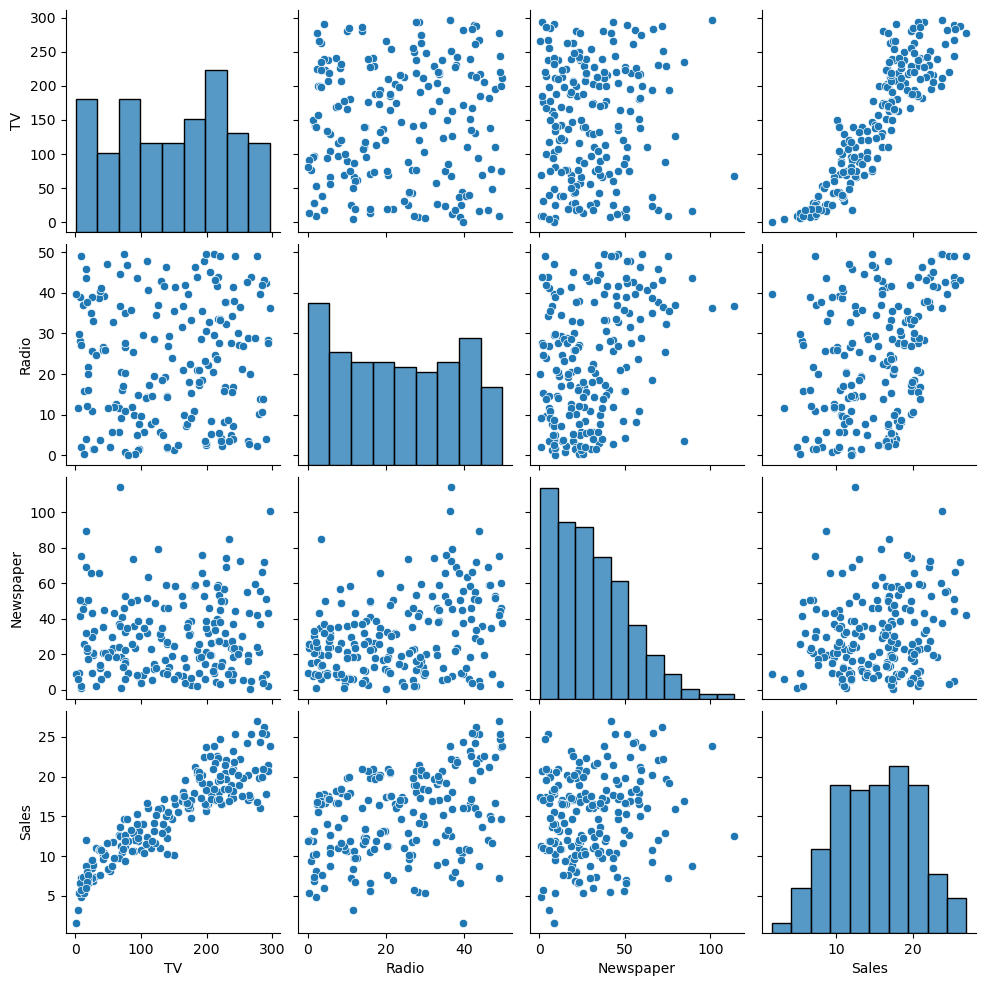

In [9]:
sns.pairplot(df)
plt.show()

<Axes: xlabel='TV', ylabel='Sales'>

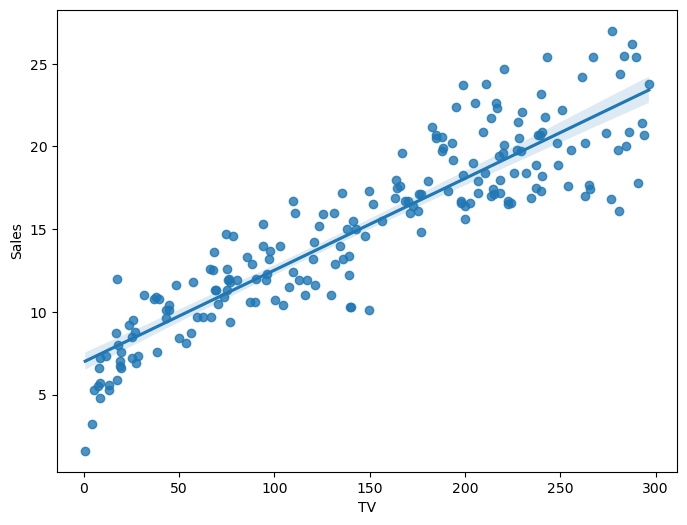

In [10]:
plt.figure(figsize=(8,6))
sns.regplot(x='TV',y='Sales',data=df)

<Axes: xlabel='Radio', ylabel='Sales'>

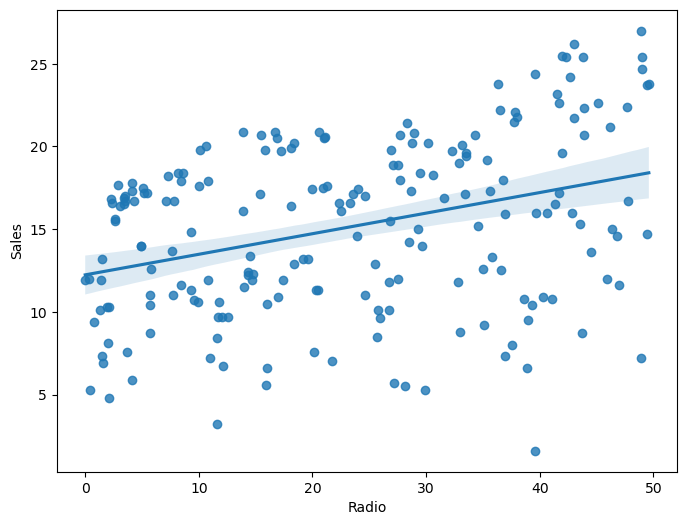

In [11]:
plt.figure(figsize=(8,6))
sns.regplot(x='Radio',y='Sales',data=df)

<Axes: xlabel='Newspaper', ylabel='Sales'>

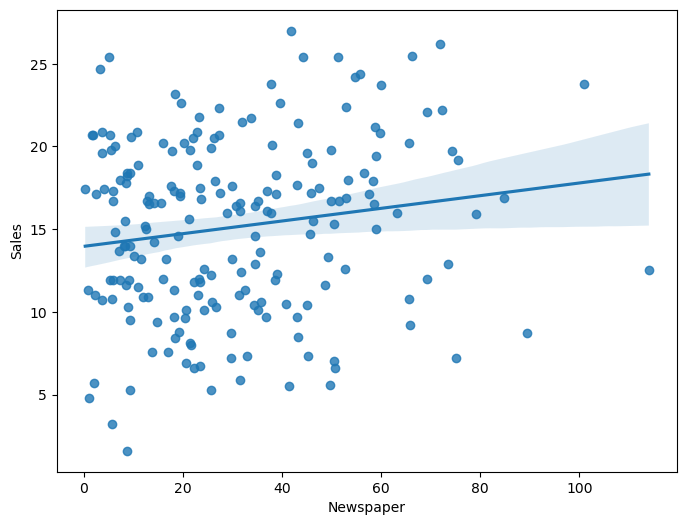

In [12]:
plt.figure(figsize=(8,6))
sns.regplot(x='Newspaper',y='Sales',data=df)

# Step 4: split the data into feature and  target 

In [13]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [14]:
X


,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [15]:
y

0      22.1
1      10.4
2      12.0
3      16.5
4      17.9
       ... 
195     7.6
196    14.0
197    14.8
198    25.5
199    18.4
Name: Sales, Length: 200, dtype: float64

# Step 5:  Split the dataset into train and test data

In [16]:
X_train,X_test,y_train,y_test= train_test_split(X,y, test_size=0.3, random_state=50)

# Step 6: Creating the model

In [17]:
lin = LinearRegression()

In [18]:
# Train the model
lin.fit(X_train, y_train)

LinearRegression()

# Prediction

In [19]:
# Predictions on testing set

test_preds = lin.predict(X_test)
test_preds

array([15.82287053, 18.38101053,  9.78264322, 12.46087358, 11.58422768,
       19.73993998, 18.3016727 ,  5.22074911, 21.14558899, 12.43584245,
       18.449478  , 15.30593478, 21.11929212, 16.09181908, 19.56127347,
       16.49356718, 12.37455046, 19.03408131,  9.64057428, 13.88616431,
       15.73422392, 10.94036592,  9.35812793, 17.26845378, 22.96256067,
       13.01166282,  9.70750539, 10.01424674, 17.01669673, 16.62431199,
       14.9024671 , 13.10502383, 10.41053844, 17.90338765,  8.93052585,
        9.7252941 , 13.24487612, 22.07299829, 10.70373996, 11.58216453,
        8.57686012, 25.2254912 ,  9.81666063, 18.2413541 , 18.18154993,
       10.88504058, 14.95607348, 19.77329341, 10.73639298,  8.06211914,
       11.22337617, 13.83362876, 17.58540343,  9.4340256 , 19.18724984,
       19.008714  , 20.23084842,  5.45075963, 23.63307214, 12.66741945])

# Step 7: Model Evaluation

In [20]:
# Evaluate the model

print('Test Accuracy:', r2_score(y_test, test_preds))

Test Accuracy: 0.9052057285496888


In [21]:
# Evaluate the model

print('Test Accuracy:', mean_absolute_error(y_test, test_preds))

Test Accuracy: 1.1160831220473182


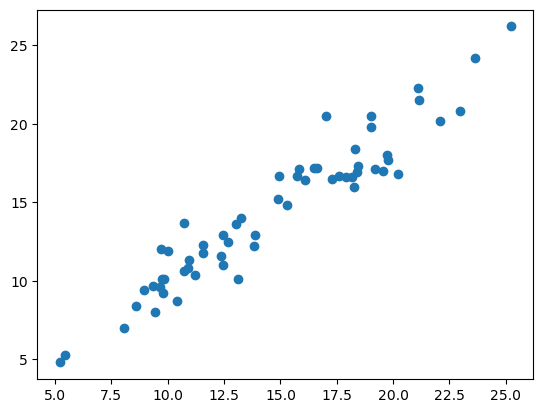

In [22]:
plt.scatter(test_preds, y_test)

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
random_model=RandomForestRegressor()

In [25]:
random_model.fit(X_train, y_train)

RandomForestRegressor()

In [26]:
# Predictions on training and testing set
train_preds = random_model.predict(X_train)
test_preds = random_model.predict(X_test)

In [27]:
# Evaluate the model
print('Train Accuracy:', r2_score(y_train, train_preds))
print('Test Accuracy:', r2_score(y_test, test_preds))

Train Accuracy: 0.9920821834554241
Test Accuracy: 0.9256702553181604


In [28]:
test_preds

array([17.593, 17.113,  8.715, 12.821, 11.445, 18.831, 18.23 ,  5.889,
       21.938, 12.758, 17.37 , 17.447, 22.37 , 17.137, 17.119, 15.665,
       12.161, 20.076,  9.687, 13.142, 14.97 , 11.927, 10.736, 16.94 ,
       19.473, 13.331, 12.525, 12.818, 19.573, 17.343, 14.061, 15.628,
        9.877, 17.824, 12.408, 10.107, 13.02 , 19.359, 11.539, 12.368,
        9.536, 25.174,  9.729, 18.441, 18.532, 10.984, 17.287, 16.742,
       11.37 ,  7.142, 10.915, 12.432, 17.421,  7.976, 18.1  , 19.691,
       16.97 ,  5.991, 24.686, 12.598])

In [29]:
# Evaluate the model

print('Test Accuracy:', mean_absolute_error(y_test, test_preds))

Test Accuracy: 0.8589166666666657


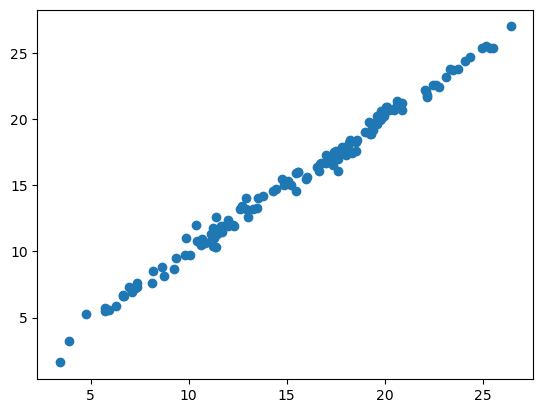

In [30]:
plt.scatter(train_preds, y_train)

In [31]:
#model saving and loading
joblib.dump(lin, 'lin_sales_detection.pkl')

['lin_sales_detection.pkl']

In [32]:
import pickle

In [34]:
pickle.dump(lin,open('linear_reg.pkl','wb'))

In [35]:
pickled_model=pickle.load(open('linear_reg.pkl','rb'))

In [36]:
pickled_model.predict(X_test)

array([15.82287053, 18.38101053,  9.78264322, 12.46087358, 11.58422768,
       19.73993998, 18.3016727 ,  5.22074911, 21.14558899, 12.43584245,
       18.449478  , 15.30593478, 21.11929212, 16.09181908, 19.56127347,
       16.49356718, 12.37455046, 19.03408131,  9.64057428, 13.88616431,
       15.73422392, 10.94036592,  9.35812793, 17.26845378, 22.96256067,
       13.01166282,  9.70750539, 10.01424674, 17.01669673, 16.62431199,
       14.9024671 , 13.10502383, 10.41053844, 17.90338765,  8.93052585,
        9.7252941 , 13.24487612, 22.07299829, 10.70373996, 11.58216453,
        8.57686012, 25.2254912 ,  9.81666063, 18.2413541 , 18.18154993,
       10.88504058, 14.95607348, 19.77329341, 10.73639298,  8.06211914,
       11.22337617, 13.83362876, 17.58540343,  9.4340256 , 19.18724984,
       19.008714  , 20.23084842,  5.45075963, 23.63307214, 12.66741945])